#### **model initation and environmental text**


In [109]:
from langchain_openai import ChatOpenAI
import os
from typing import TypedDict,List,Annotated
from operator import add
from langgraph.graph.message import add_messages
from typing import Literal, Dict
from pydantic import BaseModel, Field
from langchain_core.messages import ToolMessage,HumanMessage
from langchain_core.prompts import ChatPromptTemplate 
from datetime import datetime 
llm = ChatOpenAI(model="qwen-turbo",
                 api_key=os.getenv("DASHSCOPE_API_KEY"),
                 base_url="https://dashscope.aliyuncs.com/compatible-mode/v1")


In [110]:


class AgentTypeSchema(BaseModel):
    type: Literal['chat', 'rag', 'image'] = Field(
        ...,
        description="智能体的功能类型，用于确定处理用户请求的方式：\n"
                    "- chat: 对话交流，处理日常聊天和咨询\n"
                    "- rag: 文件处理，基于上传文件进行问答\n"
                    "- image: 图像识别，分析上传图片内容\n"
    )
    query: str = Field(description="The refined or rewritten version of the user's request.\n"
            "It should clearly describe the user's intent in a concise way.\n"
            "If the original request is ambiguous, rewrite it to make the task clearer.\n"
            "Example:\n"
            "User input: 'tell me about transformers'\n"
            "query: 'Explain the transformer architecture in machine learning.'")
    context: dict = Field(default_factory=dict, description="Additional contextual information extracted from the user request.\n"
            "Include any useful metadata needed for downstream tools or agents.\n"
            "Examples:\n"
            "- file_path: path to a document for RAG retrieval\n"
            "- image_url: URL or path of an image to analyze\n"
            "- search_source: preferred source such as arxiv or wikipedia\n"
            "If no extra context is available, return an empty dictionary {}.")
class TaskList(BaseModel):
    tasks: List[str] = Field(
        description="A sequential list of tasks that must be executed step-by-step."
    )


### schema

In [111]:


class AgentState(TypedDict):
    type: str
    query: str
    messages:Annotated[List,add_messages]
    tool_msgs:List[str]
    tasks:List[str]
    results:List[Dict[str, str]]
    task_index: int
    chat_history:List[Dict[str, str]]
structured_llm = llm.with_structured_output(AgentTypeSchema)

### **router**

In [112]:

def decide_agent_type(state: AgentState) -> AgentState:
    user_query = state["messages"][-1].content
    # 1 规则判断 type
    status = "chat"
    if "rag" in user_query:
        status = "rag"
    if "image" in user_query:
        status = "image"
    # 2 用 LLM 提取 query 和 context

    result = structured_llm.invoke(
        f"""
Extract the user's request into structured fields.

User request:
{user_query}

Return:
- query: the cleaned or refined request
- context: any useful extra information
""")
    # 3 写入 state
    state["type"] = status
    state["query"] = result.query
    #state["chat_history"].append({"user": user_query})
    state["context"] = result.context

    return state


def if_tool_call(state: AgentState)->str:
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "no_tool_call"


## **tools**

In [113]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import  ArxivAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import  WikipediaAPIWrapper
import requests
from langchain.tools import tool
from bs4 import BeautifulSoup
#the language is not limited to the English
@tool
def duck_search(query: str):
    """
    Search the web for general, recent, or real-time information.
    Use this tool when you need:
    - General knowledge not limited to a specific database
    - Recent events, news, or up-to-date information
    - Broad internet search results
    Input:
        query (str): A natural language search query.
    Returns:
        Web search results from DuckDuckGo.
    """
    search = DuckDuckGoSearchRun()
    return search.invoke(query)
@tool
def get_current_time():
    """
    Use this tool to get the current real-world time.

    This tool MUST be used for any request asking about:
    - current time
    - what time it is now
    - real-time clock information

    Do NOT guess or generate the time yourself.
    Always call this tool when such information is needed.

    Returns:
        str: current time in HH:MM:SS format
    """
    return datetime.now().strftime("%H:%M:%S")
@tool
def fetch_webpage(url: str):
    """
    Read the content of a webpage.
    Use this tool AFTER a web search when a URL is available
    and you need to read the webpage content.
    Use this tool after getting a URL from a web search
    when you need to read or summarize the webpage.
    """

    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers, timeout=10)

    soup = BeautifulSoup(response.text, "html.parser")

    for tag in soup(["script", "style"]):
        tag.decompose()

    text = soup.get_text(separator="\n")

    return text[:5000]

In [114]:
tools = [duck_search,get_current_time,fetch_webpage]
llm_tools = llm.bind_tools(tools)

## **def**


In [115]:
def check_agent_type(state: AgentState) -> str:
    agent_type = state['type']
    if agent_type == 'image':
        return 'image'
    elif agent_type == 'rag':
        return 'rag'
    else:
        return 'chat'
# def task_router(state: AgentState):
#     if state["task_index"] < len(state["tasks"]):
#         return "llm_node"
#     else:
#         return "end"
def task_router(state: AgentState) -> str:
    if state["task_index"] < len(state["tasks"]):
        history = state.get("chat_history", [])
        length = len(history)
        if(length>10):
            return "summarize_history_node"
        else :
            return "llm_node"
    else:
        return "end"



## **Node**

In [116]:

def orchestrator_node(state: AgentState) -> AgentState:
    llm_structed = llm.with_structured_output(TaskList)
    query = state["query"]
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a task planner. Break down the user request into a "
                "step-by-step todo list that a worker agent can execute sequentially."
            ),
            (
                "user",
                "User query: {query}\n"
                "Generate an ordered list of tasks to complete the request."
            )
        ]
    )
    chain = prompt | llm_structed
    result = chain.invoke({"query": query})
    state["tasks"] = result.tasks
    state["task_index"] = 0
    return state
def collect_tasks_node(state:AgentState)->AgentState:
    tasks = state["tasks"]
    query = state["query"]
    llm_structed = llm.with_structured_output(TaskList)
    prompt = ChatPromptTemplate.from_messages(
[
    (
        "system",
        "You are a task optimizer. Your job is to compress and refine a list of tasks into the minimal set of essential steps required to complete the user's goal."
    ),
    (
        "user",
        "User goal: {query}\n"
        "Task list:\n{tasks}\n\n"
        "Instructions:\n"
        "1. Keep only essential tasks that directly contribute to solving the goal.\n"
        "2. Remove redundant, overlapping, or low-value tasks.\n"
        "3. Merge similar tasks into a single, more general step when possible.\n"
        "4. Prefer fewer steps over more steps (ideal: 1–3 steps).\n"
        "5. Do NOT ask the user for more information unless it is absolutely critical to proceed.\n"
        "6. If some details are missing but can be reasonably assumed, make the assumption and proceed.\n"
        "7. Output a clean, concise, ordered list.\n\n"
        "Output format:\n"
        "1. ...\n2. ...\n"
    )
])
    chain = prompt | llm_structed
    result = chain.invoke({"query": query, "tasks": tasks})
    state["tasks"] = result.tasks
    state["task_index"] = 0
    return state
def llm_node(state:AgentState)->AgentState:  # get the tools call
    index =state["task_index"]
    message=state['tasks'][index]
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","you are a helpful asssistant that can use tools to execute question"),
            ("human","{input}")
        ]
    )
    chain = prompt|llm_tools
    response = chain.invoke({"input":message})
    state["messages"].append(response)
    return state

def tool_node(state:AgentState)->AgentState:  # receive the tools call
    messages = state['messages']
    tools_by_name = {tool.name: tool for tool in tools}
    tool_results = []
    for tool_calls in messages[-1].tool_calls: # here is the last one
        #get the real tool
        tool = tools_by_name[tool_calls["name"]]
        #give tool real query and get answer
        observation = tool.invoke(tool_calls["args"])
        tool_results.append(ToolMessage(content=observation,tool_call_id=tool_calls["id"]))

    state['tool_msgs'].append(tool_results)
    return state
# I think  the error is everywhere
        
def worker_node(state: AgentState) -> AgentState:
    tasks = state["tasks"]
    index = state["task_index"]
    task = tasks[index]

    results = state.get("results", [])
    history2 = state.get("chat_history", [])

    history_text2 = ""
    for msg in history2:
        history_text2 += f"{msg['role']}: {msg['content']}\n"
    # ====== 你原有逻辑（保持不变）======
    max_history = 3
    recent_results = results[-max_history:]

    history = ""
    for i, item in enumerate(recent_results):
        history += f"Step {index - len(recent_results) + i + 1}: {item['task']}\n"
        history += f"Result: {item['result']}\n\n"

    tool_msgs = state.get("tool_msgs", [])
    latest_tool_msg = tool_msgs[-1] if tool_msgs else "None"

    prompt = f"""
You are a task execution agent.
User goal:
{state.get("query", "")}
Conversation history:
{history_text2 if history_text2 else "None"}
Completed steps (recent):
{history if history else "None"}
Current task:
{task}
Latest tool result:
{latest_tool_msg}
Instructions:
- If a tool result is already provided, directly use it to complete the task.
- Do NOT call tools again if the result is already available.
- If no tool result is provided and the task requires external or real-time data, you should indicate that a tool is needed.
- Do NOT repeat completed work.
- Focus on solving the user's goal, not just restating the task.
- Produce only the final result of this step.
- Be concise and objective.
"""

    result = llm.invoke(prompt).content

    results.append({
        "task": task,
        "result": result
    })

    state["results"] = results
    state["task_index"] = index + 1

    if state["task_index"] == len(tasks):
        chat_history = state.get("chat_history", [])
        chat_history.append({
            "role": "user",
            "content": state.get("query", "")
        })
        chat_history.append({
            "role": "assistant",
            "content": result
        })
        state["chat_history"] = chat_history

    return state

def no_tool_call(state: AgentState) -> AgentState:  # no tool call, just execute the task
    message = "no tool call, just execute the task"
    state['tool_msgs'].append(message)
    return state

def summarize_history_node(state: AgentState) -> AgentState:
    history = state.get("chat_history", [])
    # ===== 构建原始对话文本 =====
    history_text = ""
    for msg in history:
        history_text += f"{msg['role']}: {msg['content']}\n"

    # ===== 用 LLM 做压缩 =====
    prompt = f"""
You are a conversation summarizer.

Summarize the following conversation into a concise memory that preserves:
- user intents
- key facts
- important context

Output format:
User: ...
Assistant: ...

Conversation:
{history_text}
"""

    summary = llm.invoke(prompt).content

    # ===== 保留最近一轮（避免丢当前语境）=====
    recent = history[-2:]  # 最后一问一答

    # ===== 压缩后的 memory =====
    new_history = [
        {"role": "system", "content": summary}
    ] + recent

    state["chat_history"] = new_history

    return state


## **graph**


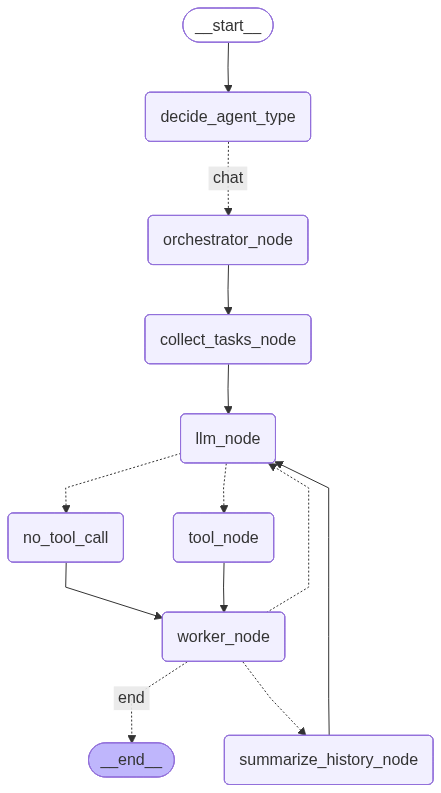

In [118]:


from langgraph.graph import StateGraph,START,END
graph = StateGraph(AgentState)
graph.add_node("decide_agent_type",decide_agent_type)
graph.add_node("worker_node",worker_node)
graph.add_node("tool_node",tool_node)
graph.add_node("llm_node",llm_node)
graph.add_node("no_tool_call",no_tool_call)
graph.add_node("orchestrator_node",orchestrator_node)
graph.add_node("collect_tasks_node",collect_tasks_node) 
graph.add_node("summarize_history_node",summarize_history_node)

graph.add_edge(START,"decide_agent_type")
graph.add_conditional_edges("decide_agent_type",check_agent_type,{"chat":"orchestrator_node"})
graph.add_edge("orchestrator_node","collect_tasks_node")
graph.add_edge("collect_tasks_node","llm_node")
graph.add_conditional_edges("llm_node",if_tool_call,{"tool_node":"tool_node","no_tool_call":"no_tool_call"})
graph.add_edge("tool_node","worker_node")
graph.add_edge("no_tool_call","worker_node")
graph.add_conditional_edges("worker_node",task_router,{"llm_node":"llm_node","end":END,"summarize_history_node":"summarize_history_node"})
graph.add_edge("summarize_history_node","llm_node")
xs_graph = graph.compile()
from IPython.display import Image,display
Image(xs_graph.get_graph().draw_mermaid_png())
#print(Image(xs_graph.get_graph().draw_mermaid()))


In [105]:
# response=xs_graph.invoke({
#     "type":"",
#     "query":"",
#     "messages":["我想知道学习ai都需要学什么，简要概述"],
#     "tasks":[],
#     "results":[],
#     "task_index": 0
# })

# for msg in response['messages']:
#     msg.pretty_print()

In [106]:
# for chunk in xs_graph.stream(
#    {
#     "type":"",
#     "query":"",
#     "messages":["我想知道现在几点了"],
#     "tasks":[],
#     "results":[],
#     "task_index": 0
# },
#     stream_mode="updates"
# ):
#     print(chunk)

In [ ]:
import sys
sys.setrecursionlimit(10000)

final_state = None  # ✅ 用来记录最终状态

for chunk in xs_graph.stream(
    {
        "type": "",
        "query": "",
        "messages": ["给我查查最近伊朗那块的战争打的怎么样了"],
        "tasks": [],
        "results": [],
        "task_index": 0,
        "tool_msgs": [],
        "chat_history": []
    },
    stream_mode="updates"
):
    for node, state in chunk.items():
        final_state = state  # ✅ 持续更新为最新 state

        print(f"\nNode: {node}")

        if state.get("query"):
            print(f"Query: {state['query']}")

        if "tasks" in state and state["tasks"]:
            print(f"Tasks ({len(state['tasks'])}):")
            for i, t in enumerate(state["tasks"], 1):
                print(f"  {i}. {t}")

        if "task_index" in state:
            print(f"Progress: Step {state['task_index']}")

        if "tool_msgs" in state and state["tool_msgs"]:
            print(f"Tool Output:")
            print(f"  → {state['tool_msgs'][-1]}")

        if "results" in state and state["results"]:
            latest = state["results"][-1]
            print(f"Result:")
            print(f"Task: {latest['task']}")
            print(f"Output: {latest['result']}")
    print("\n" + "="*30)
print("📚 Final Chat History")
print("="*30)
chat_history = final_state.get("chat_history", [])
for i, msg in enumerate(chat_history, 1):
    print(f"{i}. {msg['role']}: {msg['content']}")


Node: decide_agent_type
Query: 最近伊朗的战争情况
Progress: Step 0


Node: orchestrator_node
Query: 最近伊朗的战争情况
Tasks (6):
  1. 1. 确定用户所指的‘战争情况’具体是指哪一场冲突或事件（例如：与以色列的紧张关系、地区冲突等）。
  2. 2. 收集最新的新闻报道和官方声明，确认当前伊朗是否处于战争状态或面临军事威胁。
  3. 3. 分析伊朗近期的军事行动、外交政策及国际反应，包括可能涉及的国家（如美国、以色列、沙特等）。
  4. 4. 检查是否有联合国或其他国际组织的最新报告或声明。
  5. 5. 整理信息并总结伊朗当前的战争或冲突局势，确保内容准确、客观且基于可靠来源。
  6. 6. 将整理好的信息以清晰、简洁的方式呈现给用户。
Progress: Step 0


Node: collect_tasks_node
Query: 最近伊朗的战争情况
Tasks (3):
  1. 1. 汇集最新权威信息，确认伊朗当前是否处于战争状态或面临军事冲突，并明确具体涉及的冲突类型及相关方。
  2. 2. 整理并分析伊朗近期的军事行动、外交政策及国际社会（如美国、以色列、联合国等）的反应，确保信息准确且来源可靠。
  3. 3. 总结伊朗当前的战争或冲突局势，以清晰、客观的方式向用户呈现关键信息。
Progress: Step 0


Node: llm_node
Query: 最近伊朗的战争情况
Tasks (3):
  1. 1. 汇集最新权威信息，确认伊朗当前是否处于战争状态或面临军事冲突，并明确具体涉及的冲突类型及相关方。
  2. 2. 整理并分析伊朗近期的军事行动、外交政策及国际社会（如美国、以色列、联合国等）的反应，确保信息准确且来源可靠。
  3. 3. 总结伊朗当前的战争或冲突局势，以清晰、客观的方式向用户呈现关键信息。
Progress: Step 0


Node: tool_node
Query: 最近伊朗的战争情况
Tasks (3):
  1. 1. 汇集最新权威信息，确认伊朗当前是否处于战争状态或面临军事冲突，并明确具体涉及的冲突类型及相关方。
  2. 2. 整理并分析伊朗近期的军事行动、外交政策及国际社会（如美国、以色列、联